<a href="https://colab.research.google.com/github/mikael-pintassilgo/portfolio/blob/my-pages/colab-notebooks/Play_Store_Review_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Date of analysis: end of January 2026.

I would like to develop a mobile puzzle game for the Android platform based on Tetris shapes, but not as dynamic, where the user can think and choose the right place.
I would like it to be profitable.

To increase my chances, I analysed the information on the website
https://app.sensortower.com/top-charts?os=android&country=US&device=iphone&category=game_puzzle&date=2026-01-12
and found that the most popular games in this genre are the following:
- Block Blast! - https://app.sensortower.com/overview/com.block.juggle?country=US.
- Block Crush! - https://app.sensortower.com/overview/com.wood.block.sudoku.puzzle.bm?country=US
- Color Block Jam - https://app.sensortower.com/overview/com.GybeGames.ColorBlockJam?country=US
- Color Block: Combo Blast - https://app.sensortower.com/overview/com.puzzlegames.puzzlebrickslegend?country=US

Another game with similar dynamics is
- Unblock me (premium) - https://app.sensortower.com/overview/com.kiragames.unblockme?country=US

To understand what is good and what is bad about these games, I decided to analyse user feedback.

Below is the code I use for quick analysis of feedback on Google Play.



# Install

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 44.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
!pip install google-play-scraper pandas scikit-learn transformers torch nltk sentencepiece

In [4]:
!pip install symspellpy

# Import Libraries

In [5]:
import pandas as pd

from google_play_scraper import reviews, Sort
from urllib.parse import urlparse, parse_qs

from collections import Counter
from transformers import pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

import spacy
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.probability import FreqDist
from nltk.corpus import wordnet as wn
from nltk.stem import WordNetLemmatizer

import re
import os

import time
from datetime import datetime

from symspellpy.symspellpy import SymSpell, Verbosity

# Setup Variables

In [6]:
path = '/content/drive/MyDrive/Colab Notebooks/mobile_games_feedback_analysis/'

In [7]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

# Initialize the Porter Stemmer.
stemmer = PorterStemmer()

lemmatizer = WordNetLemmatizer()

nlp = spacy.load("en_core_web_sm", disable=["ner"])

sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)

# The original file is here: https://github.com/wolfgarbe/SymSpell/blob/master/SymSpell/frequency_dictionary_en_82_765.txt
# I placed here the version that I used: https://github.com/mikael-pintassilgo/portfolio/blob/main/data-sets/mobile_game_play_store_feedback.csv
sym_spell.load_dictionary(path + "frequency_dictionary_en_82_765.txt", term_index=0, count_index=1)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
SYNONYM_MAP = {
    "bad": {"bad", "terrible", "awful", "horrible", "annoying", "irritating"},
    "good": {"good", "great", "nice", "excellent", "fantastic", "amazing", "wonderful", "favorite", "awesome"},
    "crash": {"crash", "freeze", "hang"},
    "ad": {"ad", "ads", "advertising", "advertize", "advertisement"},
    "bug": {"bug", "issue", "problem", "error"},
    "price": {"price", "pricing", "cost"},
    "purchase": {"purchase", "payment", "pay"},
    "ui": {"ui", "interface", "menu"},
    "relax": {"relax", "relaxing", "calm down", "calmdown", "relaxation", "calming", "antistress"},
    "color": {"Color", "colour"},
}

# Defenitions

In [9]:
def get_game_id(url: str) -> str | None:
    parsed = urlparse(url)
    params = parse_qs(parsed.query)
    return params.get("id", [None])[0]

## Basic Cleaning

In [10]:
def clean_text(text):
    # all letters are converted to lowercase
    text = text.lower()

    # Let's replace "im" and "i'm" with "I am".
    text = re.sub(r"\bi'?m\b", 'I am', text, flags=re.IGNORECASE)

    # \1 refers to whatever was captured in the first set of parentheses
    # {2,} looks for 2 or more additional repetitions of that exact character
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # tokenisations and deleting stop words.
    text = re.sub(r'[^a-z ]', '', text)
    words = word_tokenize(text)
    tokens = [w for w in words if w not in stop_words]
    return " ".join(tokens)

In [11]:
def normalize_token(token):
    for canonical, variants in SYNONYM_MAP.items():
        if token in variants:
            return canonical
    return token

## Typos

In [12]:
def correct_text_sym_spell(text):
    corrected = []
    for word in text.split():
        suggestions = sym_spell.lookup(word, Verbosity.CLOSEST, max_edit_distance=2)
        corrected.append(suggestions[0].term if suggestions else word)
    return " ".join(corrected)

## Stemming

In [13]:
def stem_text(text):
    words = word_tokenize(text)

    # Apply stemmer to every word in the input text.
    stemmed_words = [stemmer.stem(word) for word in words]

    return " ".join(stemmed_words)

## Lemmatization

In [14]:
def lemmatize_text(text):
    doc = nlp(text)

    # 1. Lemmatized full text
    lemmatized_tokens = [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha and not token.is_stop
    ]
    lemmatized_text = " ".join(lemmatized_tokens)

    return lemmatized_text

In [15]:
def lemmatize_phrases(text):
    doc = nlp(text)

    # 2. Lemmatized meaningful phrases (noun chunks)
    lemmatized_phrases = []
    for chunk in doc.noun_chunks:
        phrase_tokens = [
            normalize_token(token.lemma_.lower())
            for token in chunk
            if token.is_alpha and not token.is_stop
        ]

        if len(phrase_tokens) >= 2:
            # remove single-letter words
            _words = [
                w for w in phrase_tokens
                if len(w) > 1
            ]

            if not _words:
                continue

            # remove duplicates while maintaining order
            _words = list(dict.fromkeys(_words))
            # Let's sort the words, then ‘bad game’ and ‘game bad’ will be the same.
            _words.sort()

            if len(_words) >= 2:
              lemmatized_phrases.append(" ".join(_words))

    return lemmatized_phrases


## Make Canonical

In [16]:
def get_canonical_word(word: str) -> str:
    synsets = wn.synsets(word)

    if not synsets:
        return word

    # берем самый "общий" synset (обычно первый - наиболее частотный)
    best_synset = synsets[0]

    # берем первую lemma как каноническую
    canonical = best_synset.lemmas()[0].name().lower()

    # wordnet может вернуть слова через "_" -> делаем пробел или оставляем как есть
    canonical = canonical.replace("_", " ")

    return canonical

In [17]:
def make_words_canonical(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""

    words = re.findall(r"[a-z']+", text.lower())

    result = []
    for w in words:
        canonical = get_canonical_word(w)
        result.append(canonical)

    return " ".join(result)

## Counters

In [18]:
def get_common_words(param_df, column_name):
  # Join all rows into one big string
  all_text = " ".join(param_df[column_name].dropna().astype(str)).lower()

  # Extract words with 2 or more characters
  words = re.findall(r'\b\w{2,}\b', all_text)

  # Count word frequencies
  word_counts = Counter(words)
  print("Length of the word_counts: ", len(word_counts))

  # Convert to DataFrame and sort
  common_words_df = (
      pd.DataFrame(word_counts.items(), columns=["word", "count"])
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
  )

  return common_words_df

In [19]:
def get_miningful_phrases(param_df, column_name, number_of_most_common_words = 50):
    # --------------------------------------------------
  # Flatten + count
  # --------------------------------------------------

  all_phrases = [
      phrase
      for phrase_list in df["lemmatized_phrases"]
      for phrase in phrase_list
  ]

  phrase_counts = Counter(all_phrases)
  print("Number of phrases: ", len(phrase_counts))

  # --------------------------------------------------
  # Result table
  # --------------------------------------------------

  most_common_phrases = pd.DataFrame(
      phrase_counts.most_common(number_of_most_common_words),
      columns=["phrase", "count"]
  )

  return most_common_phrases

# Scrape Reviews of Competitor Games - DO NOT DO THIS BLOCK if you want to get the same result, read the first text in this block.

Below is the code for obtaining feedback.
However, the google-play-scraper library, which is used for scraping feedback, cannot obtain data for a specific period; it takes data in batches starting with the most recent ones.
If you want to draw your own conclusions based on current reviews, then execute this block.
If you plan to analyse my conclusions, it is better to use the reviews that were collected on the date of the analysis.
To do this, you need to take the files with reviews here:
https://github.com/mikael-pintassilgo/portfolio/blob/main/data-sets/mobile_game_play_store_feedback.csv

Download them to your directory. The path to the directory must be specified in the path variable, which is declared above in the Setup Variables section.

Then execute all blocks starting with block Clean Data.

To scrape feedback on the Google Play Store, you need an app ID.
Finding a competitor's app ID (package name) is easy and completely free. In most cases, it works.
Open the competitor's game in the Google Play Store. Copy the app ID from the app URL.

**Example:**

https://play.google.com/store/apps/details?id=com.block.juggle

App ID is the value after id=

In this example, it's: **com.block.juggle**

For analysis, place the URL in the COMPETITOR_APPS dictionary in the following section.
The game ID will be obtained automatically.

For this example, I will take two games, but in a real project, it is better to take more in order to analyse more competing games or related genres.
This will allow you to identify features that users like and problems that repel users.
If you enhance the features and reduce the problems, the chances of success may be higher.

In [20]:
COMPETITOR_APPS = {
  "Block_Blust": "https://play.google.com/store/apps/details?id=com.block.juggle",
  "Block_Crush": "https://play.google.com/store/apps/details?id=com.wood.block.sudoku.puzzle.bm"
}

TARGET_REVIEWS_PER_GAME = 500
TARGET_NUMBER_OF_REVIEWS = TARGET_REVIEWS_PER_GAME * len(COMPETITOR_APPS)

In [21]:
all_dfs = []

for game_name, app_URL in COMPETITOR_APPS.items():
  app_id = get_game_id(app_URL)
  print(f"🔍 Scraping {game_name} ({app_id})")

  all_reviews = []
  continuation_token = None

  while len(all_reviews) < TARGET_NUMBER_OF_REVIEWS:
    result, continuation_token = reviews(
      app_id,
      lang='en',
      country='us',
      sort=Sort.NEWEST,
      count=200,
      continuation_token=continuation_token
    )
    all_reviews.extend(result)
    print("continuation_token: ", continuation_token)
    if continuation_token is None:
      break
    time.sleep(1)


  print(f"Collected {len(all_reviews)} reviews for {game_name}")
  df_game = pd.DataFrame(all_reviews)
  df_game['game'] = game_name
  all_dfs.append(df_game)

df = pd.concat(all_dfs, ignore_index=True)

🔍 Scraping Block_Blust (com.block.juggle)
continuation_token:  <google_play_scraper.features.reviews._ContinuationToken object at 0x7d6d664a4ac0>
continuation_token:  <google_play_scraper.features.reviews._ContinuationToken object at 0x7d6d664a50c0>
continuation_token:  <google_play_scraper.features.reviews._ContinuationToken object at 0x7d6d664a59c0>
continuation_token:  <google_play_scraper.features.reviews._ContinuationToken object at 0x7d6d664a64a0>
continuation_token:  <google_play_scraper.features.reviews._ContinuationToken object at 0x7d6d664a6b00>
Collected 1000 reviews for Block_Blust
🔍 Scraping Block_Crush (com.wood.block.sudoku.puzzle.bm)
continuation_token:  <google_play_scraper.features.reviews._ContinuationToken object at 0x7d6d664a7820>
continuation_token:  <google_play_scraper.features.reviews._ContinuationToken object at 0x7d6d5e954280>
continuation_token:  <google_play_scraper.features.reviews._ContinuationToken object at 0x7d6d5e954ac0>
continuation_token:  <google_p

In [22]:
display(df.head())
display(df.tail())

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,game
0,d39bf35a-9cce-4bd9-a92f-2c68f0d9287f,April Perez,https://play-lh.googleusercontent.com/a/ACg8oc...,its really good👍,5,0,9.1.2,2026-02-03 22:09:12,Thanks a bunch for the awesome review! 😊 Thril...,2026-02-03 22:20:42,9.1.2,Block_Blust
1,dc94179b-31d3-4613-ae3d-d4f668050604,Corban,https://play-lh.googleusercontent.com/a/ACg8oc...,it's great for stress and anxiety,5,0,9.1.5,2026-02-03 22:00:58,So glad to hear it helps you unwind! 😊 The str...,2026-02-03 22:31:35,9.1.5,Block_Blust
2,1b4afa1c-9fbe-4ff4-ba70-7b24f35352c8,Tracyuv Jackson,https://play-lh.googleusercontent.com/a/ACg8oc...,good game just to many adverts wouldn't bother...,1,0,9.1.5,2026-02-03 22:00:11,Appreciate the feedback! 🙏 We totally get how ...,2026-02-03 22:31:13,9.1.5,Block_Blust
3,11cb33a3-76f6-4c16-bdef-395360a2c206,Tj Tokeak,https://play-lh.googleusercontent.com/a/ACg8oc...,is like crazy and but it is playful,5,0,None,2026-02-03 21:56:54,Glad you're enjoying the wild and playful vibe...,2026-02-03 22:31:08,None,Block_Blust
4,abaafef5-cab0-4958-b326-6686dfb15736,ZUBAIR ALI,https://play-lh.googleusercontent.com/a/ACg8oc...,zub,5,0,9.1.0,2026-02-03 21:56:18,感谢五星好评！看到您喜欢我们的游戏真是太开心啦～如果有什么特别喜欢的玩法或者小建议，随时欢迎...,2026-02-03 22:31:28,9.1.0,Block_Blust


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,game
1995,5ab0b0b1-a0f8-41c7-84a8-dbc912d6bf50,Topsy Howard,https://play-lh.googleusercontent.com/a/ACg8oc...,Beautiful,5,0,1.8.8,2026-01-10 16:37:07,Glad you're loving the look! 🌲 Our goal was to...,2026-01-16 03:57:56,1.8.8,Block_Crush
1996,bb3a00a6-50bd-491b-bf07-42820e2c4436,Reshma Gurung,https://play-lh.googleusercontent.com/a/ACg8oc...,good 👍😊,5,0,1.8.8,2026-01-10 16:24:52,看到您的五星好评和笑脸真是让人开心！😊 感谢您的支持，玩得愉快最重要！,2026-01-16 03:58:01,1.8.8,Block_Crush
1997,81c7460e-6fbc-4ec3-943e-51d819db8e00,Teju Patel,https://play-lh.googleusercontent.com/a-/ALV-U...,thank you so much sir,5,0,1.8.5,2026-01-10 16:15:36,You're so welcome! 😊 We're really glad you're ...,2026-01-16 05:20:53,1.8.5,Block_Crush
1998,3a27eb97-e0cb-47b4-96b4-1d8f7e653a15,Aravind,https://play-lh.googleusercontent.com/a/ACg8oc...,super fantastic marbles thanks enjoy,5,0,1.8.8,2026-01-10 15:48:59,"Wow, thank you so much for the 5-star love! We...",2026-01-16 05:20:52,1.8.8,Block_Crush
1999,4367fca1-ab09-4b2c-a0fc-ecbb2195671a,Maryna Nel,https://play-lh.googleusercontent.com/a-/ALV-U...,Not what advertised. I was searching tetras li...,1,0,None,2026-01-10 15:05:58,Thanks for the honest feedback. I'm sorry the ...,2026-01-16 06:24:56,None,Block_Crush


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              2000 non-null   object        
 1   userName              2000 non-null   object        
 2   userImage             2000 non-null   object        
 3   content               2000 non-null   object        
 4   score                 2000 non-null   int64         
 5   thumbsUpCount         2000 non-null   int64         
 6   reviewCreatedVersion  1602 non-null   object        
 7   at                    2000 non-null   datetime64[ns]
 8   replyContent          1971 non-null   object        
 9   repliedAt             1971 non-null   datetime64[ns]
 10  appVersion            1602 non-null   object        
 11  game                  2000 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(8)
memory usage: 187.6+ KB


In [24]:
output_directory = path
df.to_csv("mobile_game_play_store_feedback.csv")

# Clean Data

## Start here if you want to analyse my results.

You can obtain a file with current data by executing the code in the Scrape Reviews of Competitor Games section if you want to analyse current data.
But if you want to analyse the data that I analysed, place the file ‘mobile_game_play_store_feedback.csv’ with feedback in the directory that you specified in the path variable in the Setup Variables section.
The file can be downloaded here: https://github.com/mikael-pintassilgo/portfolio/blob/main/data-sets/mobile_game_play_store_feedback.csv

In [77]:
feedback_filename = "mobile_game_play_store_feedback.csv"

df = pd.read_csv(os.path.join(path, feedback_filename))

## Clean Data

## Basic Cleaning

In [78]:
print('Lengh before dropna: ', len(df))

Lengh before dropna:  2000


In [79]:
df = df[['content', 'score', 'thumbsUpCount', 'at', 'appVersion']]
df = df.dropna()
df = df[df['content'].str.len() > 25]

In [80]:
print('Lengh after dropna: ', len(df))

Lengh after dropna:  776


In [81]:
# Basic text cleaning
df['clean_text'] = df['content'].apply(clean_text)
df = df[df['clean_text'] != '']

## Typos

In [82]:
df["clean_text"] = df["clean_text"].astype(str).apply(correct_text_sym_spell)

In [83]:
print('Lengh after basic text cleaning: ', len(df))

Lengh after basic text cleaning:  776


## Lemmatized, Stammed & Canonical Text

In [84]:
tqdm.pandas()

In [85]:
df["lemmatized_text"] = (
    df["clean_text"]
    .astype(str)
    .progress_apply(lambda x: pd.Series(lemmatize_text(x)))
)

100%|██████████| 776/776 [00:05<00:00, 129.33it/s]


In [86]:
df["lemmatized_phrases"] = (
    df["clean_text"]
    .astype(str)
    .progress_apply(lambda x: lemmatize_phrases(x))
)

100%|██████████| 776/776 [00:05<00:00, 143.72it/s]


In [87]:
df["canonical_text"] = (
    df["lemmatized_text"]
    .astype(str)
    .progress_apply(lambda x: pd.Series(make_words_canonical(x)))
)

100%|██████████| 776/776 [00:00<00:00, 2234.25it/s]


In [88]:
df["canonical_phrases"] = (
    df["canonical_text"]
    .astype(str)
    .progress_apply(lambda x: lemmatize_phrases(x))
)

100%|██████████| 776/776 [00:05<00:00, 130.63it/s]


In [89]:
df["stemmed_text"] = df["lemmatized_text"].apply(stem_text)

In [90]:
display(df.head())
display(df.tail())

,content,score,thumbsUpCount,at,appVersion,clean_text,lemmatized_text,lemmatized_phrases,canonical_text,canonical_phrases,stemmed_text
3,Great time playing and I'm always challenging my friends to see who gets the highest score!,5,0,2026-01-25 13:25:26,9.0.6,great time playing always challenging friends see gets highest score,great time play challenge friend get high score,"[good time, challenge friend, high score]",great time play challenge friend get high mark,"[challenge friend, high mark]",great time play challeng friend get high score
5,another game using misleading advertising.,1,0,2026-01-25 13:18:40,9.1.0,another game using misleading advertising,game mislead advertising,[ad mislead],game mislead ad,[ad game mislead],game mislead advertis
8,so good game 😁 i rly like it so much ♥️,5,0,2026-01-25 13:01:19,9.0.8,good game ray like much,good game ray like,[game good ray],good game beam like,[beam game good],good game ray like
21,it's amazing!!!!! so fun when ur bored and also it works without internet and there's more games too!!!!!!!!!!,5,0,2026-01-25 12:02:25,9.0.8,amazing fun or bored also works without internet there games,amazing fun bored work internet game,[fun good],amaze fun bore work internet game,[amaze bore fun game internet work],amaz fun bore work internet game
27,but in my future score become veryy slowly,2,0,2026-01-25 11:40:15,9.0.8,future score become very slowly,future score slowly,[future score],future mark slowly,[future mark],futur score slowli


,content,score,thumbsUpCount,at,appVersion,clean_text,lemmatized_text,lemmatized_phrases,canonical_text,canonical_phrases,stemmed_text
1989,Ads don't allow you to play the game.,1,0,2026-01-03 16:06:04,1.8.5,ads done allow play game,ad allow play game,[game play],ad let play game,[],ad allow play game
1992,"Too many ads, but the game is alright.",3,1,2026-01-03 15:52:27,1.8.4,many ads game alright,ad game alright,[],ad game alright,[ad alright game],ad game alright
1993,How can I get rid of these stupid ads all the time? Edit. But I cannot find the option to buy out og the ads anywhere in the game?,3,1,2026-01-03 15:29:47,1.8.5,get rid stupid ads time edit find option buy of ads anywhere game,rid stupid ad time edit find option buy ad game,"[ad stupid, edit time, buy option]",rid stupid ad time edit discovery option bargain ad game,[ad bargain discovery edit game option stupid time],rid stupid ad time edit find option buy ad game
1997,this game is nothing like the preview. the game shows cool graphics but after 75 levels it is still a plain & simple block game.,1,2,2026-01-03 14:45:13,1.8.5,game nothing like preview game shows cool graphics levels still plain simple block game,game like preview game show cool graphic level plain simple block game,"[game preview, cool graphic level, block game plain simple]",game like preview game show cool graphic degree plain simple block game,"[cool degree game graphic preview, block game plain simple]",game like preview game show cool graphic level plain simpl block game
1999,waaaaaay too many forced ads,1,1,2026-01-03 14:38:29,1.8.5,way many forced ads,way forced ad,[ad forced way],manner coerce ad,[ad coerce manner],way forc ad


In [91]:
df.to_csv(path + "after_clean_data.csv")

In [92]:
df_phrases_non_empty = df[df['lemmatized_phrases'].apply(lambda x: len(x) >= 1)]
print('Length of df_phrases_non_empty: ', len(df_phrases_non_empty))
print("DataFrame with rows containing one or more lemmatized phrases:")
display(df_phrases_non_empty[['clean_text', 'lemmatized_phrases']].head())
df_phrases_non_empty.to_csv(path+"df_phrases_non_empty.csv")

Length of df_phrases_non_empty:  641
DataFrame with rows containing one or more lemmatized phrases:


,clean_text,lemmatized_phrases
3,great time playing always challenging friends see gets highest score,"[good time, challenge friend, high score]"
5,another game using misleading advertising,[ad mislead]
8,good game ray like much,[game good ray]
21,amazing fun or bored also works without internet there games,[fun good]
27,future score become very slowly,[future score]


# Calculations

## Most Common Words - Clean Text & Canonical Text - For Fast Simple Analysis

In [93]:
common_words_df = get_common_words(df, 'clean_text')

print("\nTop 50 words:")
display(common_words_df.head(50))

Length of the word_counts:  1740

Top 50 words:


,word,count
0,game,657
1,ads,260
2,fun,164
3,like,143
4,love,128
5,play,125
6,good,105
7,time,89
8,great,80
9,block,77


In [94]:
print("====================")
print("== CANONICAL TEXT ==")
print("====================\n")
common_words_df = get_common_words(df, 'canonical_text')

print("\nTop 50 words:")
display(common_words_df.head(50))

== CANONICAL TEXT ==

Length of the word_counts:  1262

Top 50 words:


,word,count
0,game,701
1,ad,299
2,play,194
3,fun,164
4,like,150
5,good,137
6,love,130
7,block,117
8,time,102
9,great,82


In [95]:
# Let's analyse the feedback that contain the word ‘change’.
display(df[df['canonical_text'].apply(lambda x: True if 'change' in x else False)][['content', 'canonical_text']].head(20).style.set_properties(**{"text-align": "left"}))

,content,canonical_text
104,"i love the color change of tiles once it's completely cleared, and the additional games, too!",love color change tile wholly clear extra game
113,this used to be such a great game my default go to time killer but now themes change without my request it behaves as if it has a mind of its own and sometimes I don't even get to finish any level cause it's now a network based game you have to be connected to play my favourite adventure puzzles and the adventure puzzles theme was constant now it just flips and changes making it hard to stay on the game a long time. it would be great if I could choose my theme & it stayed till I change,great game default time killer subject change request act mind coating degree cause network base game connect play front-runner adventure puzzle adventure puzzle subject constant somersault change brand difficult stay game hanker time great choose subject stay till change
211,it a nice game and it it the way it advertised changing blocks each time is very interesting,nice game manner advertise change block time interest
276,when I play the game there was so many ads and all the ads on YouTube are fakes and pls Don't put ads in your games this game is bad and why this game have ads and I'm mad BC the games ads are annoying I hate this game I'm installing your game have shopping showing when I'm playing your game I'm uninstalling your game forever change everything I say are I never playing your trash game again,play game ad ad youtube fake asset ad game game bad game ad huffy game ad annoyance hate game installation game shopping show playing game uninstalling game everlastingly change play rubbish game
459,I like the game with we will feel sad and we will play that every single day so I like that game even you have to go to high school you have to change colors when you finish with that color you have to change it to Pink what I like that game so much I think I will play every single day and this is my phone I wish I amen,like game feel sad play single day like game high school change color coating color change pink like game think play single day telephone wish aman
608,"I respect this game. not alotta ads, tons of side games, and the cool feature of how the background color changes if you get all the blocks out 😎👌",respect game lotta ad short ton game cool feature background color change block
793,"this game changed my life. I was alive but not truly living. I was merely existing, that was until this game came in and lifted the veil of my life. Everything seemed brighter, happier, like my life was unfinished before then. Now my life is full of joy, Now I can live my life to the fullest, without regret nor worry.",game change life alive truly populate merely exist game come lift head covering life bright happy like life unfinished life joy populate life full moon sorrow concern
807,this game is sooooo fun an addictive! I wish I could change the color of the blocks tho.,game fun addictive wish change color block tho
847,"at first it was a great game, ads were not frequent, but after a couple days and more than a couple rounds later thd ads show up constantly after every game, and the gameplay changed, before it was random blocks, but then it felt the blocks are not random anymore, you have to ""solve"" certain blocks and then the game threw a big 3x3 or a long 1x5 to end the game and straight to commercials.",great game ad patronize couple day couple round later ad constantly game gamelan change random block feel block random anymore solve certain block game throw large hanker end game heterosexual commercial
867,"Block Blast starts as a satisfying, colorful distraction, but the charm wears off incredibly fast. The mechanics are simple—fit blocks to clear lines—yet it lacks the depth or progression needed to sustain interest. Within 15 minutes, you’ve seen everything the game has to offer. Without meaningful stakes or varied power-ups, the gameplay becomes a repetitive loop

Highlits about the 'change' word:
- Don't like that theme was changed without player's request.
- One player likes how the background color changes if you get all the blocks out.
- One player wants to rotate blocks.
- Some players don't like colors.
- Some players don't like that the game does not work without internet connection.

## Most Common Meaningful Words - Lemmatized Text

In [96]:
vectorizer = CountVectorizer(
    stop_words="english",
    min_df=5,          # ignore rare words
    #max_df=0.8,         # ignore too-common words
    token_pattern=r"(?u)\b[a-zA-Z]{3,}\b"
)

X = vectorizer.fit_transform(df["lemmatized_text"])

word_freq = (
    pd.DataFrame({
        "word": vectorizer.get_feature_names_out(),
        "count": X.sum(axis=0).A1
    })
    .sort_values("count", ascending=False)
)


In [97]:
len(word_freq)

221

In [98]:
print("Top 50 words:")
display(word_freq.head(50))

Top 50 words:


,word,count
88,game,700
147,play,194
87,fun,164
116,like,150
90,good,137
124,love,130
23,block,116
198,time,100
92,great,82
3,add,55


It is worth analysing separately the feedback that mentions the words relax, change, advertise, wifi, and others.

Usually, users do not like very intrusive advertising. And they like it when they can play without the internet (in this case, you can disable advertising by turning off the internet).

If users write that they play the game to relax, for example, while returning from work or after a hard day, then this can be considered a characteristic for which players choose the game.

If I want my game to be suitable for the same target audience, it should not be too difficult, so that players can relax while playing my game, rather than getting stressed.

In [99]:
# Let's analyse the feedback that contain the word ‘relax’.
display(df[df['lemmatized_text'].apply(lambda x: True if 'relax' in x else False)][['content']].head(20).style.set_properties(**{"text-align": "left"}))

,content
36,its relaxing and it makes me feel calm I love block blast
88,amazing game no ads it's relaxing and perfect
92,It's so relaxing to be in bed playing this fun game block blast just all the colors make my day so much better than it has been all ready keep it up block blast
125,I love this game cause I play it when I'm bored cause I don't have anything good on my tablet and I love block blast cause it's relaxing and it's better than any game I have I hate when I lose tho but I love when it helps me when it gives me the blocks I need bye bye.
137,it's relaxing and fun to play
170,Great game if you want to calm down and relax but no wifi needed
288,very relaxing game I love it everyday I play this when I'm stressed
303,Its just so relaxing and its so good and addictive if you download this game it will be very addictive this game is great if I could give 10 stars I would
342,this game is really relaxing for me you must try it out
354,This game is incredible and unbelievable 👏 it is relaxing it removes stress


Judging by the reviews, players really do use the game to relax and calm down.
If I want to make a similar game, I need to take this fact into account and try to preserve this effect in the game so as not to lose this part of the audience.
When I analyse feedback from my game, it is also worth paying attention to how often the word ‘relax’ appears in the feedback.

## Most Common Miningful Phrases - Lemmatized Phrases & Canonical Phrases

In [100]:
most_common_phrases = get_miningful_phrases(df, 'lemmatized_phrases', 50)

print("Most common 50")
print(most_common_phrases)

Number of phrases:  957
Most common 50
               phrase  count
0           game good     65
1           game love     29
2            fun game     20
3         blast block     10
4          high score      8
5        ad game good      8
6             ad game      7
7      game good love      6
8            bad game      5
9           game play      5
10            ad mind      5
11           fun play      4
12             ad fun      4
13            ad good      4
14           fun good      3
15           fun time      3
16            fun lot      3
17   game interesting      3
18   game good little      3
19     favourite game      3
20      fun game good      3
21           ad false      3
22       ad game love      3
23     fun play super      2
24       download fun      2
25          long time      2
26            ad hate      2
27         game think      2
28      game good way      2
29          ad minute      2
30       game playing      2
31           game lot      2
32  

In [101]:
most_common_phrases = get_miningful_phrases(df, 'canonical_phrases', 50)

print("Most common 50")
print(most_common_phrases)

Number of phrases:  957
Most common 50
               phrase  count
0           game good     65
1           game love     29
2            fun game     20
3         blast block     10
4          high score      8
5        ad game good      8
6             ad game      7
7      game good love      6
8            bad game      5
9           game play      5
10            ad mind      5
11           fun play      4
12             ad fun      4
13            ad good      4
14           fun good      3
15           fun time      3
16            fun lot      3
17   game interesting      3
18   game good little      3
19     favourite game      3
20      fun game good      3
21           ad false      3
22       ad game love      3
23     fun play super      2
24       download fun      2
25          long time      2
26            ad hate      2
27         game think      2
28      game good way      2
29          ad minute      2
30       game playing      2
31           game lot      2
32  

It is worth analysing reviews that contain phrases such as ‘bad game’ to identify features that can be changed in your game to make it better than your competitors.

In [102]:
# Let's analyse the feedback that contain the phrase ‘bad game’.
display(df[df['lemmatized_text'].apply(lambda x: True if 'bad game' in x else False)][['content', 'lemmatized_text', 'lemmatized_phrases']].head(20).style.set_properties(**{"text-align": "left"}))

,content,lemmatized_text,lemmatized_phrases
152,worst game yet I get an ad game after every single level n can't exit out of it unless I close the game down and start it again.,bad game game single level not exit close game start,['bad game']
276,when I play the game there was so many ads and all the ads on YouTube are fakes and pls Don't put ads in your games this game is bad and why this game have ads and I'm mad BC the games ads are annoying I hate this game I'm installing your game have shopping showing when I'm playing your game I'm uninstalling your game forever change everything I say are I never playing your trash game again,play game ad ad youtube fake plus ad game game bad game ad mad game ad annoying hate game installing game shopping show playing game uninstalling game forever change play trash game,"['ad game', 'game shopping', 'game playing', 'game trash']"
634,bad game sometimes they didn't have solution when the score 900000,bad game didst solution score,"['bad game', 'score solution']"


'bad game' highlights:
- lots of ads.
- unable to exit the game.
- problems with scoring.

In [103]:
# Let's analyse the feedback that contain the phrase ‘bad experience.
display(df[df['lemmatized_text'].apply(lambda x: True if 'bad experience' in x else False)][['content', 'lemmatized_text', 'lemmatized_phrases']].head(20).style.set_properties(**{"text-align": "left"}))

,content,lemmatized_text,lemmatized_phrases
384,bad experience .too Many problems .fix the game zz,bad experience problem fix game zzz,['bad experience']


In [104]:
# Let's analyse the feedback that contain the word ‘color’.
display(df[df['lemmatized_text'].apply(lambda x: True if 'color' in x else False)][['content', 'clean_text']].head(20).style.set_properties(**{"text-align": "left"}))

,content,clean_text
92,It's so relaxing to be in bed playing this fun game block blast just all the colors make my day so much better than it has been all ready keep it up block blast,relaxing bed playing fun game block blast color make day much better ready keep block blast
104,"i love the color change of tiles once it's completely cleared, and the additional games, too!",love color change tiles completely cleared additional games
459,I like the game with we will feel sad and we will play that every single day so I like that game even you have to go to high school you have to change colors when you finish with that color you have to change it to Pink what I like that game so much I think I will play every single day and this is my phone I wish I amen,like game feel sad play every single day like game even go high school change color finish color change pink like game much think play every single day phone wish amen
608,"I respect this game. not alotta ads, tons of side games, and the cool feature of how the background color changes if you get all the blocks out 😎👌",respect game lotta ads tons side games cool feature background color changes get blocks
699,"A really good game 🎮🎯🧠👀 I'm now a really good problem solver. Definitely raises your IQ 💪 I really appreciate it, and it also has other options of games, like color sort, fruit merge, to name a few. Ads barely pop up. Total time killer 🔥🔥🔥Best game in the whole world 🌍🌎 It is a a puzzle game so if you like games like this game, I would suggest you download it today 📱😸❤️🩷💜🧠 later or tonight even,😜😆🤣💪🔥",really good game really good problem solver definitely raises in really appreciate also options games like color sort fruit merge name ads barely pop total time killer best game whole world puzzle game like games like game would suggest download today later tonight even
739,I love this game but I think the ads are too frequent and I see ads for this game that you can select one color pattern but that sadly is true:/,love game think ads frequent see ads game select one color pattern sadly true
807,this game is sooooo fun an addictive! I wish I could change the color of the blocks tho.,game fun addictive wish could change color blocks tho
1441,"addictive , I couldn't stop playing but it has changed I'm uninstalling, I wish we could turn off the new graphics, specifically the match undulations and flashes of color, they distract from the pleasant simplicity of what this once was that made it great",addictive couldn't stop playing changed uninstalling wish could turn new graphics specifically match undulations flashes color distract pleasant simplicity made great
1880,this game is so much fun i love it i love how the blocks change colors and i love the whole game i cant believe this game is free in in the App Store i love block Crush,game much fun love love blocks change color love whole game cant believe game free app store love block crush
1898,"it's my safe place when I'm stressed, bored or have free time. it's so addicting and the idea of changing colors is great to not get bored >⁠.⁠< but i have questions 1-in the challenges it says sometimes you beat 95% of players , is this real or just programmed because it's an offline game how do you compare with other players 2-in danger or challenge comes when it's hard choices but sometimes it doesn't say anything but the blocks given is completely impossible to solve",safe place stressed bored free time addicting idea changing color great get bored questions challenges says sometimes beat players real programmed offline game compare players danger challenge comes hard choices sometimes doesn't say anything blocks given completely impossible solve


'color' highlits:
- There are players who like the colour scheme in the game.
- But there are also players who ask for customisation.

## Most Common Meaningful Phrases - Statistical Approach - Lemmatized Text

In [105]:
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 3),
    min_df=5,
    max_df=0.9
)

X = vectorizer.fit_transform(df["lemmatized_text"])

phrase_freq = (
    pd.DataFrame({
        "phrase": vectorizer.get_feature_names_out(),
        "count": X.sum(axis=0).A1
    })
    .sort_values("count", ascending=False)
)

In [106]:
print("Numbere of frases: ", len(phrase_freq))
print("Most common ", 50)
phrase_freq.head(50)

Numbere of frases:  84
Most common  50


,phrase,count
65,love game,55
50,good game,55
9,block blast,45
52,great game,42
59,like game,35
32,game fun,33
25,game ad,33
72,play game,29
44,game play,28
21,fun game,21


This analysis often contains phrases that refer to advertising.
Most likely, there is a lot of advertising in the games being analysed. If I show less advertising in my game, it is possible that my game will receive a higher rating, even if it is no different from the games being analysed.

There is also the expression ‘high score’. Since this game has a mode where you can play ‘endlessly’ to achieve a high score, it is worth analysing this feedback carefully. I will do this further on in the notebook.

## Most Common Meaningful Phrases - Linguistic Approach - Lemmatized Text

In [107]:
nlp = spacy.load("en_core_web_sm")

def extract_phrases(texts):
    phrases = []
    for doc in nlp.pipe(texts, batch_size=1000):
        for chunk in doc.noun_chunks:
            phrase = chunk.text.lower()
            if len(phrase.split()) > 1:
                phrases.append(phrase)
    return phrases

phrases = extract_phrases(df["lemmatized_text"].dropna())

phrase_counts = Counter(phrases)

most_common_phrases = pd.DataFrame(
    phrase_counts.most_common(50),
    columns=["phrase", "count"]
)

In [108]:
print("Number of phrases: ", len(phrase_counts))
print("Most common ", 50)
display(most_common_phrases)

Number of phrases:  1027
Most common  50


,phrase,count
0,love game,14
1,good game,12
2,great game,10
3,game fun,9
4,fun game,6
5,high score,5
6,game advertise,5
7,block blast,4
8,game help,4
9,nice game,4


It is worth analysing some of the most critical reviews separately, in which players write, for example, about deleting the game.

In [109]:
# Let's analyse the feedback that contain the word ‘delete’.
pd.set_option("display.max_colwidth", None)
display(df[df['lemmatized_text'].apply(lambda x: True if 'delete' in x else False)][['content']].style.set_properties(**{"text-align": "left"}))

,content
994,"I did LOVE this game. My score was over 300,000. I cleared the data and it reset the game. Now every classic game gives me an unsolvable puzzle. I reached out and reported the bug, no reply from them. Deleting the game."
1007,"I was hoping to play the big Tetris like game they advertised, but I haven't seen it yet. If it's not an actual part of this game, if like many other games it was just false advertising then I will stop playing it and just delete the game? But I've only been playing for an hour so I'll give it another day to find out then I'll update my review accordingly."
1151,"the game is fun but the ads make it unplayable. multiple minutes of wait for every ad. Deleting right now, regretfully."
1225,"when I 'm playing 🎴,fill in all empty, yet they give me square box, don't fit 😞 & that cheating, especially when there no where to put it, on the first try, Than the adds burn my battery 🪫🔋 not cool,l have to watch 3/ ads,U lost a player it's not 🚫 too many bugs 🐛🐛 & it going in the garbage, fix the 🪲🐛🐛 & just maybe 🤔💭 I,' ll b back 🔙 now it's deleted, ⁉️🚨"
1243,I have loved this game and have played it for months but it froze today and I had to uninstall the app and download it again and it started my levels over. And it's still freezing. So frustrating. I'm about to just delete it.
1377,"to many ads good game but let down by the ads that keep coming, time to delete"
1403,I love this game it was amazing but I delete it from my phone because it show ads for along time and I have to wait it until finish it is boring for me
1408,"Ads, ads and more ads. Doesn't matter whether you win or lose. Ads!!!!! Greed is why I am deleting. It's a shame because the game is really good."
1453,AD is so different! it doesn't not look like the ADS at all. I played for like 20 minutes and deleted it. I hate false advertisements
1808,please stop defaulting the background music on everytime you close the app! this is so frustrating and making me want to stop using it. the other sounds stay off but BGM turns on as soon as you reopen the app. when will this be fixed its horrible and driving me nuts to the point I will soon be deleting the game.


In [110]:
# Let's analyse the feedback that contain the word ‘uninstal’.
display(df[df['lemmatized_text'].apply(lambda x: True if 'uninstal' in x else False)][['content']].style.set_properties(**{"text-align": "left"}))

,content
276,when I play the game there was so many ads and all the ads on YouTube are fakes and pls Don't put ads in your games this game is bad and why this game have ads and I'm mad BC the games ads are annoying I hate this game I'm installing your game have shopping showing when I'm playing your game I'm uninstalling your game forever change everything I say are I never playing your trash game again
578,the ads are a joke up to 3mins long rapidly uninstalled
635,"it would be a 5 but the long adverts every round just ruin it so uninstalled. if no adverts or short adverts would still be playing. uodate reinsralled December 2025 and adverts even worse. great game but waste if time adverts are so long. so yep, uninstalled again wont reinstall again."
649,"It's fun, but i refuse to be disrespected by unskippable popups, especially when you ALREADY have a bar ad on the bottom. Edit: you're still doing the same thing. uninstalled and ignored forevermore"
724,"love the game, hate the ads. just too many and skipping is not an option after watching 1 minute long Temu ads. I'm uninstalling."
917,love the game.. really hate the ads. give me a game that I can purchase without the ads. on the verge of uninstalling it
1054,"absolute rubbish nothing like the video and forced adverts that you can't skip, straight to uninstall !"
1077,No ads for 2 or 3 levels than another games ad starts after every gane you play ... god bless uninstall button
1114,the recent update (1/22/26) that happened mid game play is awful. this went from being my absolute favorite block game to one of the worst in just a moment. I have completely lost interest and will uninstall. trash app
1243,I have loved this game and have played it for months but it froze today and I had to uninstall the app and download it again and it started my levels over. And it's still freezing. So frustrating. I'm about to just delete it.


Players delete the game for the following reasons:
- Too many advertisements.
- Points are reset during updates or other actions taken by developers.
- Advertising materials for the game do not provide accurate information about what will be in the game if they install it.
- The music cannot be turned off.

Since the game has an endless mode in which points are counted, it is worth checking out what players write about points and leaderboards if these phrases appear at the top.

In [111]:
# Let's analyse the feedback that contain the phrase ‘high score’.
display(df[df['lemmatized_text'].apply(lambda x: True if 'high score' in x else False)][['content']].style.set_properties(**{"text-align": "left"})
)

,content
3,Great time playing and I'm always challenging my friends to see who gets the highest score!
141,can you add one thing it is when you get a new high score it lights up the whole entire screen and does a big congratulations like way bigger
159,"the updates to block slide have ruined the experience. way more difficult, but not in a good way. too many spots to fill with the blocks given and can no longer try and chase your own high score. no longer fun."
286,"My highest score so far is 12.208.860 played in an hour, Is that good one? Idk, I wish that score can be converted into real money lol"
440,this game hates androids they make it so easy for apple players to get a high score while android doesn't even start with a blank board if it was the same I would give 5 stars
475,"Very fun and very addictive puzzle game (my high score is 454,947)"
506,"THANK YOU DEVELOPERS for quickly fixing the touch problems. All is even better than before with your addition of the NEW REALLY COOL GRAPHICS when I clear the board. I wish I could sign in to the game on my free tablet, so that my high score could show there also. But that's no biggie. 😊"
548,It is a great game. It gives you high scores. you should definitely download it.😃😃
776,"block blast is a brain solving game. It's very easy and fun. Also, you challenge you family and friends about your highest score. All in all, block blast is so fun.💖✨️😊"
781,"so much fun. can play for hours. ads can be annoying but you can get past them and its not so bad. fun to challenge friends on high score or just to play on a car ride or waiting for the bus. solid over all, I had alot of fun playing with my friends too."


Highlights:
- Players like high scores.
- They compete with their loved ones and friends for points.
- Players pay attention if the points are not counted correctly.
- Players get upset if they cannot beat their record for a long time.

It is worth paying close attention to the scoring system and showing players interesting animations when they manage to beat their record.

Similarly, lines containing other frequently occurring phrases can be analysed.

## Sentiment Analysis

In [112]:
sentiment_model = pipeline("sentiment-analysis") # Uncomment this line if you want to use the defoult settings. And also comment the next line.
#sentiment_model = pipeline(
#    "sentiment-analysis",
#    model="siebert/sentiment-roberta-large-english",
#    tokenizer="siebert/sentiment-roberta-large-english"
#)
#sentiment_model = pipeline(
#    "sentiment-analysis",
#    model="siebert/sentiment-roberta-large-english",
#    tokenizer="siebert/sentiment-roberta-large-english",
#    device=0  # set -1 if no GPU
#)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [113]:
sentiment_start = datetime.now()

sentiments = sentiment_model(
    df['lemmatized_text'].tolist(),
    batch_size=32,
    truncation=True
)

df["sentiment"] = [s["label"] for s in sentiments]
df["sentiment_score"] = [
    s["score"] if s["label"] == "POSITIVE" else -s["score"]
    for s in sentiments
]

sentiment_end = datetime.now()
print(f"Sentiment analysis took {sentiment_end - sentiment_start}")

Sentiment analysis took 0:00:46.938784


In [114]:
df[['sentiment', 'lemmatized_text', 'sentiment_score']].head()

,sentiment,lemmatized_text,sentiment_score
3,POSITIVE,great time play challenge friend get high score,0.999685
5,NEGATIVE,game mislead advertising,-0.999278
8,POSITIVE,good game ray like,0.999850
21,POSITIVE,amazing fun bored work internet game,0.999545
27,NEGATIVE,future score slowly,-0.994164


In [115]:
df['sentiment'].value_counts()

,count
sentiment,
POSITIVE,494
NEGATIVE,282


In [116]:
propotions = df['sentiment'].value_counts(normalize=True)
print(propotions)

sentiment
POSITIVE    0.636598
NEGATIVE    0.363402
Name: proportion, dtype: float64


Information about the distribution of positive and negative reviews can be used as a benchmark for your own game.
If you have more positive reviews, it means that you have achieved better results than your competitors.
If you have fewer, then you have room for growth. Continue to analyse and experiment.

In [117]:
# top positive and negative feedback
top_positive = df.sort_values('sentiment_score', ascending=False)[['content', 'sentiment', 'sentiment_score', "lemmatized_text"]].head(10)
top_negative = df.sort_values('sentiment_score', ascending=True)[['content', 'sentiment', 'sentiment_score', "lemmatized_text"]].head(10)

print('Top positive feedback:')
display(
    top_positive[['sentiment_score', "content", "lemmatized_text"]]
        .style
        .set_properties(**{"text-align": "left"})
)
print('\nTop negative feedback:')
display(
    top_negative[['sentiment_score', "content", "lemmatized_text"]]
        .style
        .set_properties(**{"text-align": "left"})
)

Top positive feedback:


,sentiment_score,content,lemmatized_text
1091,0.999887,"Great, intense game, love it !!",great intense game love
467,0.999885,I love it so much very fun,love fun
723,0.999885,game is amazing i love it so much its so satisfing,game amazing love satisfy
1486,0.999884,I love it and i really enjoy,love enjoy
536,0.999884,it's a great game I love it,great game love
893,0.999883,wonderful life time enjoy the game pf block blast,wonderful life time enjoy game block blast
1544,0.999883,super fantastic marbles thanks enjoy,super fantastic marble thank enjoy
1796,0.999882,I really do love this game it's an awesome game,love game awesome game
1753,0.999882,"addictive, stimulating and good fun",addictive stimulate good fun
1178,0.999882,certainly once I get more experience and enjoyment !,certainly experience enjoyment



Top negative feedback:


,sentiment_score,content,lemmatized_text
1476,-0.999814,This game is NOT what they show in their ad! Just another stupid blocks and not those collapsing once like the developer pretends. annoying ad yet misleading!,game stupid block collapse like developer pretend annoying misleading
696,-0.999806,too bad the actual game IS NOTHING LIKE THE AD.,bad actual game like
1631,-0.999798,Deceiving ads. It's nothing like the ad. The graphics are bad and the sounds and music are horrible.,deceive ad like graphic bad sound music horrible
428,-0.999797,nothing like the ad's. lame,like ad lame
1917,-0.999789,way too many ads so im deleting the game sadly.,way ad delete game sadly
1764,-0.999779,really badd not like shown in advertisement video 😤 vary baddd,add like show advertisement video vary bad
1715,-0.999778,to irritating for all!!!!!!!?.,irritate
937,-0.999761,I like to waste lifely time on this:),like waste likely time
1940,-0.999760,Nothing like the ads. Waste of my time. Would have given my rating for the game itself if they hadn't been dishonest with their ads.,like ad waste time give rating game haunt dishonest ad
1248,-0.999747,stupid game. regular boring same old same old.,stupid game regular boring old old


In [118]:
df.to_csv(path + "after_sentiment_analysis.csv")

## Phareses Analiser: Sentiment Score and TF-IDF and Frequency

In [119]:
# --------------------------------------------------
# 4. TF-IDF for phrases
# --------------------------------------------------

tfidf = TfidfVectorizer(
    min_df=2,
    max_df=0.9,
    ngram_range=(1, 3)
)

In [120]:
# ==================================================
# Main pipeline
# ==================================================
def analyze_reviews(df):

    # ---- Phrase extraction ----
    phrase_rows = []
    for idx, phrases in df["lemmatized_phrases"].items():
        for phrase in phrases:
            #print(idx, phrases)
            phrase_rows.append({"doc_id": idx, "phrase": phrase})

    phrase_df = pd.DataFrame(phrase_rows)

    phrase_df["sentiment"] = phrase_df["doc_id"].map(df["sentiment_score"])
    tfidf_matrix = tfidf.fit_transform(phrase_df["phrase"])
    phrase_df["tfidf"] = tfidf_matrix.max(axis=1).toarray().flatten()

    # ---- Aggregate phrases ----
    final = (
        phrase_df
        .groupby("phrase")
        .agg(
            frequency=("phrase", "count"),
            avg_tfidf=("tfidf", "mean"),
            avg_sentiment=("sentiment", "mean")
        )
        .reset_index()
    )

    # ---- Importance ranking ----
    final["importance"] = (
        final["frequency"]
        * final["avg_tfidf"]
        * final["avg_sentiment"].abs()
    )

    final = final.sort_values("importance", ascending=False)

    return final

In [121]:
# ==================================================
# Run
# ==================================================

final = analyze_reviews(df)

<Axes: >

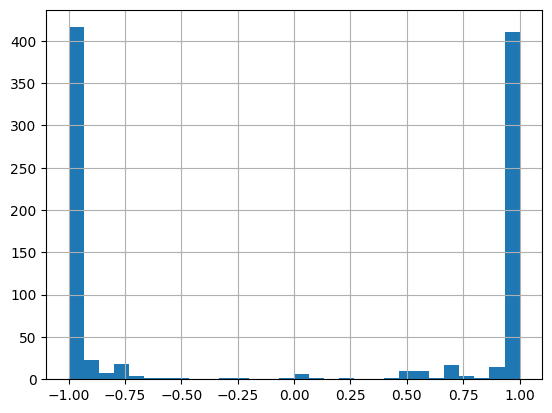

In [122]:
final["avg_sentiment"].hist(bins=30)

In [123]:
neg_threshold = final["avg_sentiment"].quantile(0.15)
pos_threshold = final["avg_sentiment"].quantile(0.85)

print('neg_threshold: ', neg_threshold)
print('pos_threshold: ', pos_threshold)

neg_threshold:  -0.9982908884684245
pos_threshold:  0.9996722221374512


In [124]:
# ---- Split praise vs complaints ----
top_complaints = final[final["avg_sentiment"] < neg_threshold]
top_praises    = final[final["avg_sentiment"] > pos_threshold]

In [125]:
print("\n🔥 TOP COMPLAINTS")
print(top_complaints.head(20)[
    ["phrase", "frequency", "avg_sentiment"]
])

print("\n✨ TOP PRAISES")
print(top_praises.head(20)[
    ["phrase", "frequency", "avg_sentiment"]
])



🔥 TOP COMPLAINTS
               phrase  frequency  avg_sentiment
116         ad minute          2      -0.999072
935     recent update          2      -0.999283
130           ad show          1      -0.999779
61       ad dishonest          1      -0.999760
239   avoid guarantee          1      -0.999741
853       intro video          1      -0.999733
316       block float          1      -0.999732
721      game idiotic          1      -0.999697
225          app icon          1      -0.999666
941    score solution          1      -0.999657
800   generated voice          1      -0.999605
746          game mid          1      -0.999605
773     game shopping          1      -0.999524
358        bpm reason          1      -0.999472
352       boring wifi          1      -0.999447
618     fps low saggy          1      -0.999431
888    manually place          1      -0.999396
237    auto damn game          1      -0.999372
117        ad mislead          1      -0.999278
6    absolute rubbish 

In [126]:
# Let's analyse the feedback that contain the word ‘error’.
display(df[df['lemmatized_text'].apply(lambda x: True if 'error' in x else False)][['content']].head(20).style.set_properties(**{"text-align": "left"}))

,content
1281,This game having software error


In [127]:
final.head(10)

,phrase,frequency,avg_tfidf,avg_sentiment,importance
677,game good,65,0.677579,0.769666,33.898124
738,game love,29,0.726047,0.513510,10.812126
630,fun game,20,0.734145,0.698764,10.259895
83,ad game,7,0.793511,-0.996756,5.536562
270,blast block,10,0.609689,0.801331,4.885627
246,bad game,5,0.723709,-0.989045,3.578902
691,game good love,6,0.595242,0.999872,3.570998
98,ad good,4,0.839684,0.999404,3.356737
80,ad fun,4,0.805836,0.938817,3.026131
663,fun play,4,0.749740,0.993195,2.978552


In [128]:
final.tail(10)

,phrase,frequency,avg_tfidf,avg_sentiment,importance
857,kaldryorum uygulamay,1,0.0,-0.987667,0.0
516,deil kaybedince okumutum oynanmyor relay srekli var yorumlarda,1,0.0,-0.987667,0.0
494,correct observation,1,0.0,-0.985189,0.0
493,coronation eye,1,0.0,0.999797,0.0
337,blok flask helen ski tetrisin yukardan,1,0.0,-0.987667,0.0
443,class match,1,0.0,0.999774,0.0
948,shove throat,1,0.0,-0.968710,0.0
481,complicated hell,1,0.0,-0.956776,0.0
905,myselfthis proudhon,1,0.0,-0.966777,0.0
15,achievement perseverance,1,0.0,0.994306,0.0


# Findings

**Distribution of positive and negative reviews**

Feedback contains 64% positive reviews and 36% negative reviews. When developing a new game, I need to try to increase the percentage of positive reviews to look better than my competitors.

**Relax and Calm Down**

Judging by the reviews, players really do use the game to relax and calm down. If I want to make a similar game, I need to take this fact into account and try to preserve this effect in the game so as not to lose this part of the audience.
For example, do not add narrative part to this game.

When I analyse feedback from my game, it is also worth paying attention to how often the word ‘relax’ appears in the feedback.

**Bad game**

Users say the game is bad for the following reasons:
- Lots of ads.
- Unable to exit the game.
- Problems with scoring.

Since I am also planning to monetise through advertising, I need to analyse in more detail what users don't like, so that there is a balance between playing time and viewing ads, keeping users happy while still making the game profitable.

It may be worth making the exit from the game explicit by placing the button in a prominent place. Although this is not a common pattern in mobile casual games.

Information about high scores is provided below in this section.

**Delete or Uninstall**

Players delete the game for the following reasons:
- Too many advertisements.
- Points are reset during updates or other actions taken by developers.
- Advertising materials for the game do not provide accurate information about what will be in the game if they install it.
- The music cannot be turned off.

Players should be able to turn off background music and other sounds that may be in the game.

**High Score**

Highlights:
- One of the important goals for players is to score as many points as possible.
- They compete with their loved ones and friends for points.
- Players pay attention if the points are not counted correctly.
- Players get upset if they cannot beat their record for a long time.

It is worth paying close attention to the scoring system and showing players interesting animations when they manage to beat their record.

When releasing updates, special care must be taken to ensure that they do not reset or distort players' high scores.

**Color**

- There are players who like the colour scheme in the game.
- But there are also players who ask for customisation.
- There was a player who did not like that theme was changed without player's request.

It is likely that part of the audience could be attracted if the game offered the option to choose the colour of the shapes, first and foremost, and highlighted this option in marketing materials.

**More**
- Block Rotation.
- Work without internet connection.

# Additional work

The approach described above allows you to quickly see the main problems that players write about in their feedback, as well as what they love or praise about the game.

You can then conduct a more in-depth analysis and manually analyse the feedback, assigning categories manually in a separate column.

Alternatively, you can set tags in the first few hundred lines of feedback and train a model on them, which can then predict categories on its own.

You can use the category information to calculate which categories occur more frequently.
It is best to focus your efforts on the most popular categories first, as they affect a larger number of users.

P.S.
Google's data contains release information. If you want to analyze information about a specific release, such as the latest release, you should add a filter by the "appVersion" column.